# HHE Lab Sardinia — Marine Litter Hazard Assessment
**Data cleaning → EDA → Spatial Hazard Index**

Inputs: `Labenv/Modulo_4_*` (beach) · `Labenv/Modulo_2bis_*` (floating)  
Outputs: `data/processed/` CSVs · `data/figures/` PNGs · `data/sardinia_hazard_index.html`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
import seaborn as sns
import geopandas as gpd
import folium
from matplotlib.colors import LinearSegmentedColormap
from shapely.geometry import Point, box
from scipy.spatial import cKDTree
from geodatasets import get_path
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

ROOT   = Path('..').resolve()
LABENV = ROOT / 'Labenv'
OUT    = ROOT / 'data' / 'processed'
FIGS   = ROOT / 'data' / 'figures'
MAPS   = ROOT / 'data'
OUT.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)

BEACH_COLORS = {
    'MWE_SAR_1': '#e74c3c', 'MWE_SAR_2': '#3498db',
    'MWE_SAR_3': '#2ecc71', 'MWE_SAR_4': '#f39c12',
    'MWE_SAR_5': '#9b59b6', 'MWE_SAR_6': '#1abc9c'
}
BEACH_NAMES = {
    'MWE_SAR_1': 'Alghero Lido',          'MWE_SAR_2': 'Cagliari Poetto',
    'MWE_SAR_3': 'Castiadas Costa Rei',   'MWE_SAR_4': 'Oristano Is Arenas',
    'MWE_SAR_5': 'San Teodoro La Cinta',  'MWE_SAR_6': 'S.A. Arresi Porto Pino'
}

def norm(df, rename, keep):
    df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})
    return df[[c for c in keep if c in df.columns]]

---
## 1. Beach Litter — Cleaning (Modulo_4)

In [2]:
MOD4_DIR = LABENV / 'Modulo_4_2020_Med_Occ_2018-2023'

SPIAGGIA_RENAME = {
    'Latitudine': 'lat', 'Longitudine': 'lon',
    'NomeSpiaggia': 'beach_name', 'CodiceSpiaggia': 'beach_id',
    'Regione': 'region', 'Comune': 'municipality'
}
CAMP_RENAME = {
    'SampleID': 'survey_id', 'CodiceCampionamento': 'survey_id',
    'Year': 'year', 'Anno': 'year',
    'Month': 'month', 'Mese': 'month',
    'Day': 'day', 'Giorno': 'day',
    'LunghezzaTransetto': 'transect_m', 'Lunghezza': 'transect_m',
    'CodiceSpiaggia': 'beach_id', 'CodiceStagione': 'season'
}
RIFIUTI_RENAME = {
    'SampleID': 'survey_id', 'CodiceCampionamento': 'survey_id',
    'JointListCategory': 'category', 'IDCategoriaRifiuto': 'category',
    'NumeroOggetti': 'n_items', 'NumeroItems': 'n_items',
    'Sorgente': 'source'
}

beach_frames = []
for f in sorted(MOD4_DIR.glob('*.xl*')):
    engine = 'xlrd' if f.suffix == '.xls' else 'openpyxl'
    try:
        xl       = pd.ExcelFile(f, engine=engine)
        spiaggia = norm(xl.parse('Spiaggia'), SPIAGGIA_RENAME,
                        ['beach_id','beach_name','lat','lon','region','municipality'])
        camp     = norm(xl.parse('SpiaggiaCamp'), CAMP_RENAME,
                        ['survey_id','beach_id','year','month','day','season','transect_m'])
        rifiuti  = norm(xl.parse('RifiutiCamp'), RIFIUTI_RENAME,
                        ['survey_id','category','n_items','source'])
    except Exception as e:
        print(f'ERROR {f.name}: {e}'); continue

    items = (rifiuti.groupby('survey_id')['n_items'].sum()
             .reset_index().rename(columns={'n_items': 'total_items'}))
    df = camp.merge(items, on='survey_id', how='left')
    df = df.merge(spiaggia, on='beach_id', how='left')
    df['transect_m'] = pd.to_numeric(df['transect_m'], errors='coerce').fillna(100)
    df['items_per_100m'] = df['total_items'] / df['transect_m'] * 100
    beach_frames.append(df)

beach_df = pd.concat(beach_frames, ignore_index=True)
beach_df = beach_df.dropna(subset=['year', 'total_items'])
beach_df['year'] = beach_df['year'].astype(int)

coords = beach_df.dropna(subset=['lat','lon']).groupby('beach_id')[['lat','lon']].first()
for idx, row in beach_df[beach_df['lat'].isna()].iterrows():
    if row['beach_id'] in coords.index:
        beach_df.at[idx, 'lat'] = coords.loc[row['beach_id'], 'lat']
        beach_df.at[idx, 'lon'] = coords.loc[row['beach_id'], 'lon']

beach_df.to_csv(OUT / 'beach_litter.csv', index=False)
print(f"Beach: {len(beach_df)} surveys · {beach_df['beach_id'].nunique()} beaches · years {sorted(beach_df['year'].unique())}")
beach_df.head()

Beach: 41 surveys · 6 beaches · years [2020, 2021, 2022, 2023]


,survey_id,beach_id,transect_m,total_items,beach_name,municipality,items_per_100m,year,month,day,season,lat,lon,region
73,MWE_SAR_2_2020_1PRI,MWE_SAR_2,100,256.0,Cagliari Poetto,Cagliari,256.0,2020,5.0,22.0,1PRI,39.212500,9.174720,NaN
74,MWE_SAR_3_2020_1PRI,MWE_SAR_3,100,34.0,Castiadas Costa Rei,Muravera,34.0,2020,5.0,26.0,1PRI,39.264160,9.581380,NaN
75,MWE_SAR_4_2020_1PRI,MWE_SAR_4,100,590.0,Oristano Is Arenas,Narbolia,590.0,2020,5.0,27.0,1PRI,40.069520,8.478710,NaN
76,MWE_SAR_5_2020_1PR1,MWE_SAR_5,100,23.0,San Teodoro La Cinta,San Teodoro,23.0,2020,5.0,21.0,1PRI,40.788277,9.670278,NaN
77,MWE_SAR_6_2020_1PR1,MWE_SAR_6,100,67.0,Sant'Anna Arresi Porto Pino,Sant'Anna Arresi,67.0,2020,5.0,28.0,1PRI,38.958790,8.611670,NaN


---
## 2. Floating Litter — Cleaning (Modulo_2bis)

In [3]:
MOD2BIS_DIR = LABENV / 'Modulo_2bis_2020_Med_Occ_2018-2023'

STAZ_RENAME = {
    'NationalStationID': 'station_id', 'NationalStationName': 'station_name',
    'Latitude': 'lat_station', 'Longitude': 'lon_station',
    'Region': 'region', 'SeaDepth': 'depth_m'
}
MACROFLOT_RENAME = {
    'NationalStationID': 'station_id', 'COD_Effort': 'effort_id',
    'ID_Transect': 'transect_id', 'Survey_N': 'survey_n',
    'Latitude': 'lat', 'Longitude': 'lon',
    'Day': 'day', 'Month': 'month', 'Year': 'year',
    'Material': 'material', 'ComposizioneLivI': 'material',
    'IDCategoriaRifiuto': 'category',
    'Size': 'size', 'Grandezza': 'size',
    'Buoyancy': 'buoyancy', 'Galleggiamento': 'buoyancy',
    'Source_lit': 'source', 'Sorgente': 'source',
    'Strip': 'strip_width_m', 'Mean_speed': 'speed_knots',
    'Time_effective': 'time_obs'
}
MACROFLOT_KEEP = [
    'station_id','effort_id','transect_id','survey_n',
    'lat','lon','day','month','year',
    'material','category','size','buoyancy','source',
    'strip_width_m','speed_knots','time_obs'
]
MAT_MAP = {
    'Polimeri artificiali': 'Artificial polymer',
    'Materiale naturale':   'Natural matter',
    'Alghe/Fanerogame':     'Natural matter',
    'Legno lavorato':       'Processed wood',
    'Rifiuto alimentare':   'Food waste',
    'Gomma':                'Rubber',
    'Metallo':              'Metal',
    'Vetro/ceramica':       'Glass/ceramics',
    'Tessile':              'Textiles',
    'Carta/cartone':        'Paper/cardboard',
}

import re

def _year_month_from_stem(stem):
    """Extract year and month from filename like '2019_03_...' or 'ID2756_2019_03_...'"""
    nums = re.findall(r'\b(\d{4})\b.*?(\d{1,2})\b', stem)
    if nums:
        return int(nums[0][0]), int(nums[0][1])
    return np.nan, np.nan

float_frames = []
for f in sorted(MOD2BIS_DIR.glob('*.xl*')):
    engine = 'xlrd' if f.suffix == '.xls' else 'openpyxl'
    try:
        xl       = pd.ExcelFile(f, engine=engine)
        stazioni = norm(xl.parse('Stazioni'), STAZ_RENAME,
                        ['station_id','station_name','lat_station','lon_station','region','depth_m'])
        sheet = 'MacroFlotCamp' if 'MacroFlotCamp' in xl.sheet_names else 'MacroplasticheFlotCamp'
        mf = norm(xl.parse(sheet), MACROFLOT_RENAME, MACROFLOT_KEEP)
        if 'year' not in mf.columns:
            yr, mo = _year_month_from_stem(f.stem)
            mf['year'] = yr; mf['month'] = mo
    except Exception as e:
        print(f'ERROR {f.name}: {e}'); continue
    float_frames.append(mf.merge(stazioni, on='station_id', how='left'))

float_df = pd.concat(float_frames, ignore_index=True)
float_df['material'] = float_df['material'].replace(MAT_MAP)
float_df['year']  = pd.to_numeric(float_df['year'],  errors='coerce').astype('Int64')
float_df['month'] = pd.to_numeric(float_df['month'], errors='coerce').astype('Int64')
float_df.to_csv(OUT / 'floating_litter.csv', index=False)
print(f"Floating: {len(float_df)} obs · {float_df['station_id'].nunique()} stations · years {sorted(float_df['year'].dropna().unique())}")
float_df.head()

Floating: 1060 obs · 25 stations · years [2021, 2022, 2023]


,station_id,lat,lon,material,size,buoyancy,source,year,month,station_name,...,region,depth_m,effort_id,transect_id,survey_n,day,category,strip_width_m,speed_knots,time_obs
0,"0004-MS00200_TR_1,5",39.192950,9.209100,Artificial polymer,C,POS,T,<NA>,<NA>,"Cagliari_1,5",...,Sardegna,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"0004-MS00200_TR_1,5",39.191867,9.209267,Artificial polymer,C,NEU,I,<NA>,<NA>,"Cagliari_1,5",...,Sardegna,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0256-MS01640_TR06,38.960133,8.509600,Artificial polymer,B,NEU,I,<NA>,<NA>,Porto Botte_06,...,Sardegna,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0004-MS00200_TR06,39.130717,9.216800,Artificial polymer,D,POS,T,<NA>,<NA>,Cagliari_06,...,Sardegna,54.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"0073-MS00370_TR_0,5",39.956389,9.697222,Artificial polymer,C,NEU,T,<NA>,<NA>,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# effort duration = max-min sighting time per effort_id
float_df['time_dt'] = pd.to_datetime(float_df['time_obs'], format='%H:%M:%S', errors='coerce')
effort_dur = (
    float_df.dropna(subset=['time_dt'])
    .groupby('effort_id')['time_dt']
    .agg(lambda x: (x.max() - x.min()).total_seconds() / 3600)
    .reset_index().rename(columns={'time_dt': 'duration_h'})
)
effort_meta = (
    float_df.groupby('effort_id').agg(
        n_items=('effort_id','count'),
        strip_width_m=('strip_width_m','mean'),
        speed_knots=('speed_knots','mean'),
        year=('year','first'), month=('month','first'),
        station_id=('station_id','first'),
        lat_station=('lat_station','first'),
        lon_station=('lon_station','first'),
        region=('region','first')
    ).reset_index()
)
effort_meta = effort_meta.merge(effort_dur, on='effort_id', how='left')
effort_meta['area_km2'] = (
    effort_meta['strip_width_m'] *
    effort_meta['speed_knots'] * 1852 *
    effort_meta['duration_h']
) / 1e6
effort_meta['density_km2'] = effort_meta['n_items'] / effort_meta['area_km2'].replace(0, np.nan)
effort_meta.to_csv(OUT / 'floating_litter_efforts.csv', index=False)
print(f'Efforts: {len(effort_meta)}')
effort_meta[['n_items','area_km2','density_km2']].describe().round(3)

Efforts: 656


,n_items,area_km2,density_km2
count,656.000,600.000,5.000
mean,1.047,0.001,801.315
std,0.239,0.016,867.952
min,1.000,0.000,5.108
25%,1.000,0.000,154.273
50%,1.000,0.000,607.451
75%,1.000,0.000,1079.914
max,4.000,0.392,2159.827


---
## 3. Coverage summary

In [5]:
beach    = beach_df.copy()
floating = float_df.copy()

print('=== BEACH LITTER ===')
print(f'  Surveys : {len(beach)}')
print(f'  Beaches : {beach["beach_id"].nunique()}')
print(f'  Years   : {sorted(beach["year"].unique())}')
print(f'  items/100m: {beach["items_per_100m"].describe().round(1).to_dict()}')

print('\n=== FLOATING LITTER ===')
print(f'  Observations: {len(floating)}')
print(f'  Efforts     : {len(effort_meta)}')
print(f'  Stations    : {floating["station_id"].nunique()}')
print(f'  Years       : {sorted(floating["year"].dropna().unique())}')
print(f'  % Plastic   : {(floating["material"]=="Artificial polymer").mean()*100:.1f}%')

pivot = beach.pivot_table(index='beach_id', columns='year',
                          values='items_per_100m', aggfunc='mean').round(1)
pivot

=== BEACH LITTER ===
  Surveys : 41
  Beaches : 6
  Years   : [2020, 2021, 2022, 2023]
  items/100m: {'count': 41.0, 'mean': 284.1, 'std': 272.9, 'min': 23.0, '25%': 77.0, '50%': 210.0, '75%': 384.0, 'max': 1421.0}

=== FLOATING LITTER ===
  Observations: 1060
  Efforts     : 656
  Stations    : 25
  Years       : [2021, 2022, 2023]
  % Plastic   : 68.4%


year,2020,2021,2022,2023
beach_id,,,,
MWE_SAR_1,526.0,687.0,470.5,384.0
MWE_SAR_2,257.0,183.0,315.5,281.0
MWE_SAR_3,96.0,295.5,148.5,135.5
MWE_SAR_4,635.5,734.0,393.5,391.5
MWE_SAR_5,36.0,28.0,86.5,65.0
MWE_SAR_6,65.0,187.0,321.0,260.5


---
## 4. Beach Litter — Trend per stazione

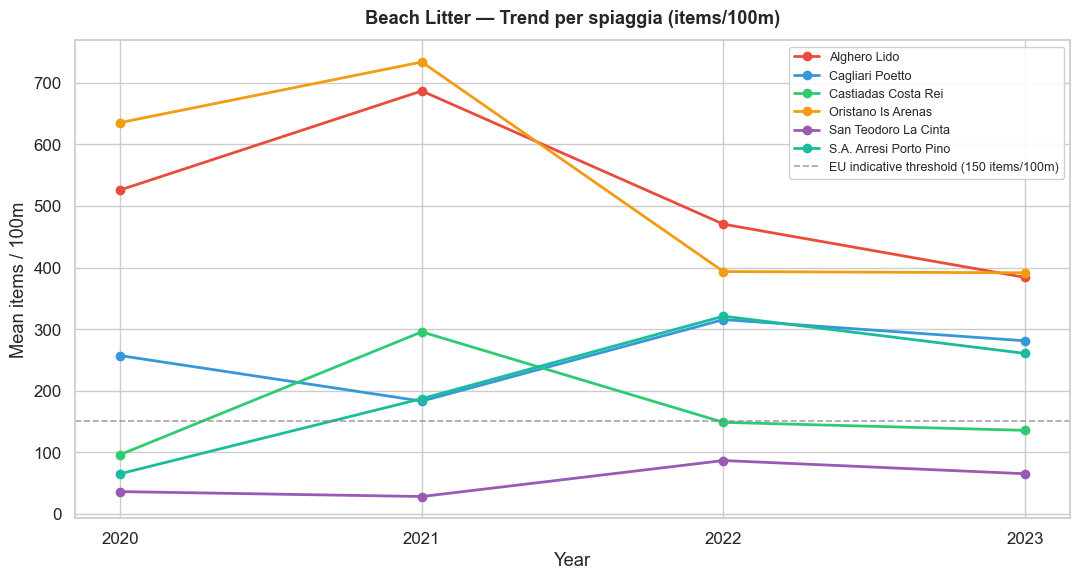

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
yearly = beach.groupby(['beach_id','year'])['items_per_100m'].mean().reset_index()
for bid, grp in yearly.groupby('beach_id'):
    ax.plot(grp['year'], grp['items_per_100m'],
            marker='o', linewidth=2,
            color=BEACH_COLORS.get(bid, '#666'),
            label=BEACH_NAMES.get(bid, bid))
ax.axhline(150, color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
           label='EU indicative threshold (150 items/100m)')
ax.set_title('Beach Litter — Trend per spiaggia (items/100m)', fontweight='bold', pad=12)
ax.set_xlabel('Year'); ax.set_ylabel('Mean items / 100m')
ax.set_xticks(yearly['year'].unique())
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'beach_trend_per_station.png', dpi=150)
plt.show()

## 5. Beach Litter — Distribuzione per anno

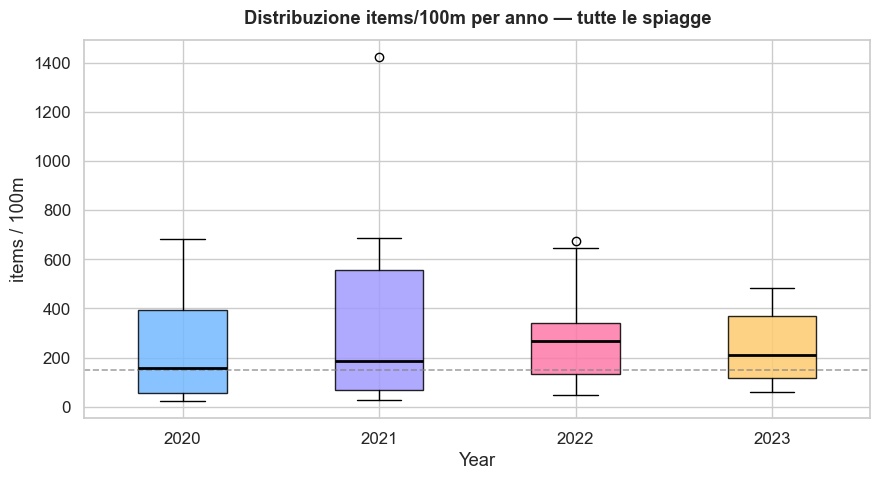

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
years_sorted = sorted(beach['year'].unique())
data_by_year = [beach[beach['year']==y]['items_per_100m'].dropna().values for y in years_sorted]
bp = ax.boxplot(data_by_year, tick_labels=years_sorted, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#74b9ff','#a29bfe','#fd79a8','#fdcb6e','#55efc4','#fab1a0']):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax.axhline(150, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_title('Distribuzione items/100m per anno — tutte le spiagge', fontweight='bold', pad=12)
ax.set_xlabel('Year'); ax.set_ylabel('items / 100m')
plt.tight_layout()
plt.savefig(FIGS / 'beach_boxplot_year.png', dpi=150)
plt.show()

## 6. Beach Litter — Top categorie (item-level)

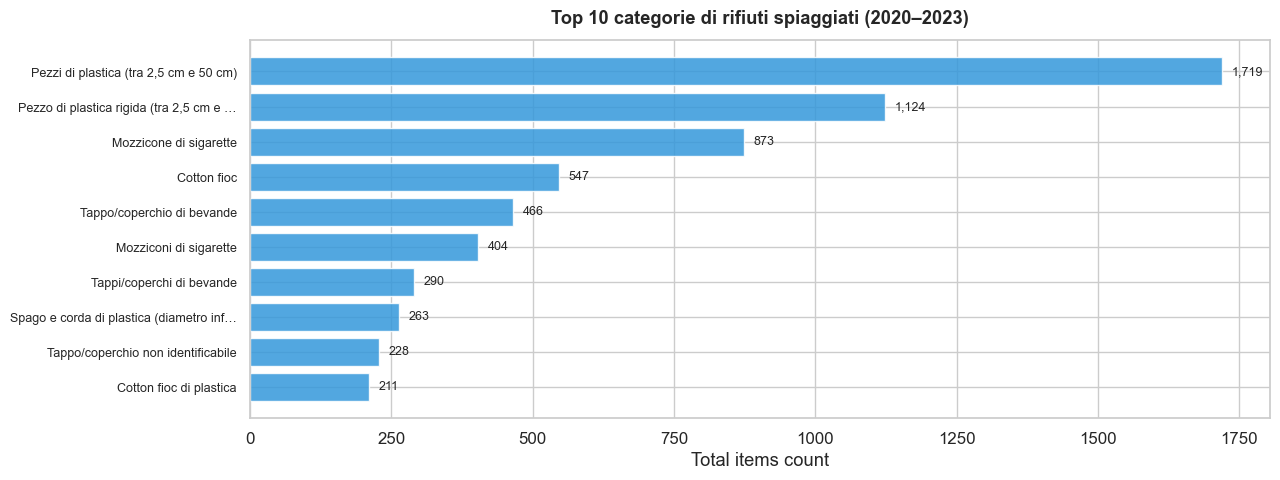

In [8]:
rif_frames = []
for f in sorted(MOD4_DIR.glob('*.xl*')):
    engine = 'xlrd' if f.suffix == '.xls' else 'openpyxl'
    try:
        xl   = pd.ExcelFile(f, engine=engine)
        rif  = norm(xl.parse('RifiutiCamp'), RIFIUTI_RENAME, ['survey_id','category','n_items','source'])
        camp = norm(xl.parse('SpiaggiaCamp'),
                    {'SampleID':'survey_id','CodiceCampionamento':'survey_id','Year':'year','Anno':'year','CodiceSpiaggia':'beach_id'},
                    ['survey_id','beach_id','year'])
        rif_frames.append(rif.merge(camp, on='survey_id', how='left'))
    except: pass

rif_df = pd.concat(rif_frames, ignore_index=True)
rif_df['n_items'] = pd.to_numeric(rif_df['n_items'], errors='coerce').fillna(0)
rif_df['year']    = pd.to_numeric(rif_df['year'],    errors='coerce')
rif_df = rif_df.dropna(subset=['year'])   # drop 2018-2019 rows where merge loses year
rif_df['year'] = rif_df['year'].astype(int)

# code → description lookup (G codes from 2020, J codes from 2022)
_df_g = pd.read_excel(MOD4_DIR / '2020_11_Modulo 4_Sardegna.xlsx',
                      sheet_name='lista_categorie_rifiuti', engine='openpyxl')[['Valore','Descrizione']]
_df_j = pd.read_excel(MOD4_DIR / '2022_11_Modulo4_Sardegna.xls',
                      sheet_name='lista_categorie_rifiuti_2022', engine='xlrd')[['Valore','Descrizione']]
_cat_desc = (pd.concat([_df_g, _df_j])
             .drop_duplicates('Valore')
             .set_index('Valore')['Descrizione']
             .to_dict())

MAX_LABEL = 40
def _label(code):
    d = _cat_desc.get(str(code).strip(), code)
    return d if len(d) <= MAX_LABEL else d[:MAX_LABEL-1] + '…'

rif_df['desc'] = rif_df['category'].map(_label)
cat_total = rif_df.groupby('desc')['n_items'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
top10 = cat_total.head(10)
bars = ax.barh(top10.index[::-1], top10.values[::-1], color='#3498db', alpha=0.85)
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(val + top10.max()*0.01, bar.get_y()+bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)
ax.set_title('Top 10 categorie di rifiuti spiaggiati (2020–2023)', fontweight='bold', pad=12)
ax.set_xlabel('Total items count')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'beach_top_categories.png', dpi=150)
plt.show()

## 7. Beach Litter — Top 10 categorie per anno

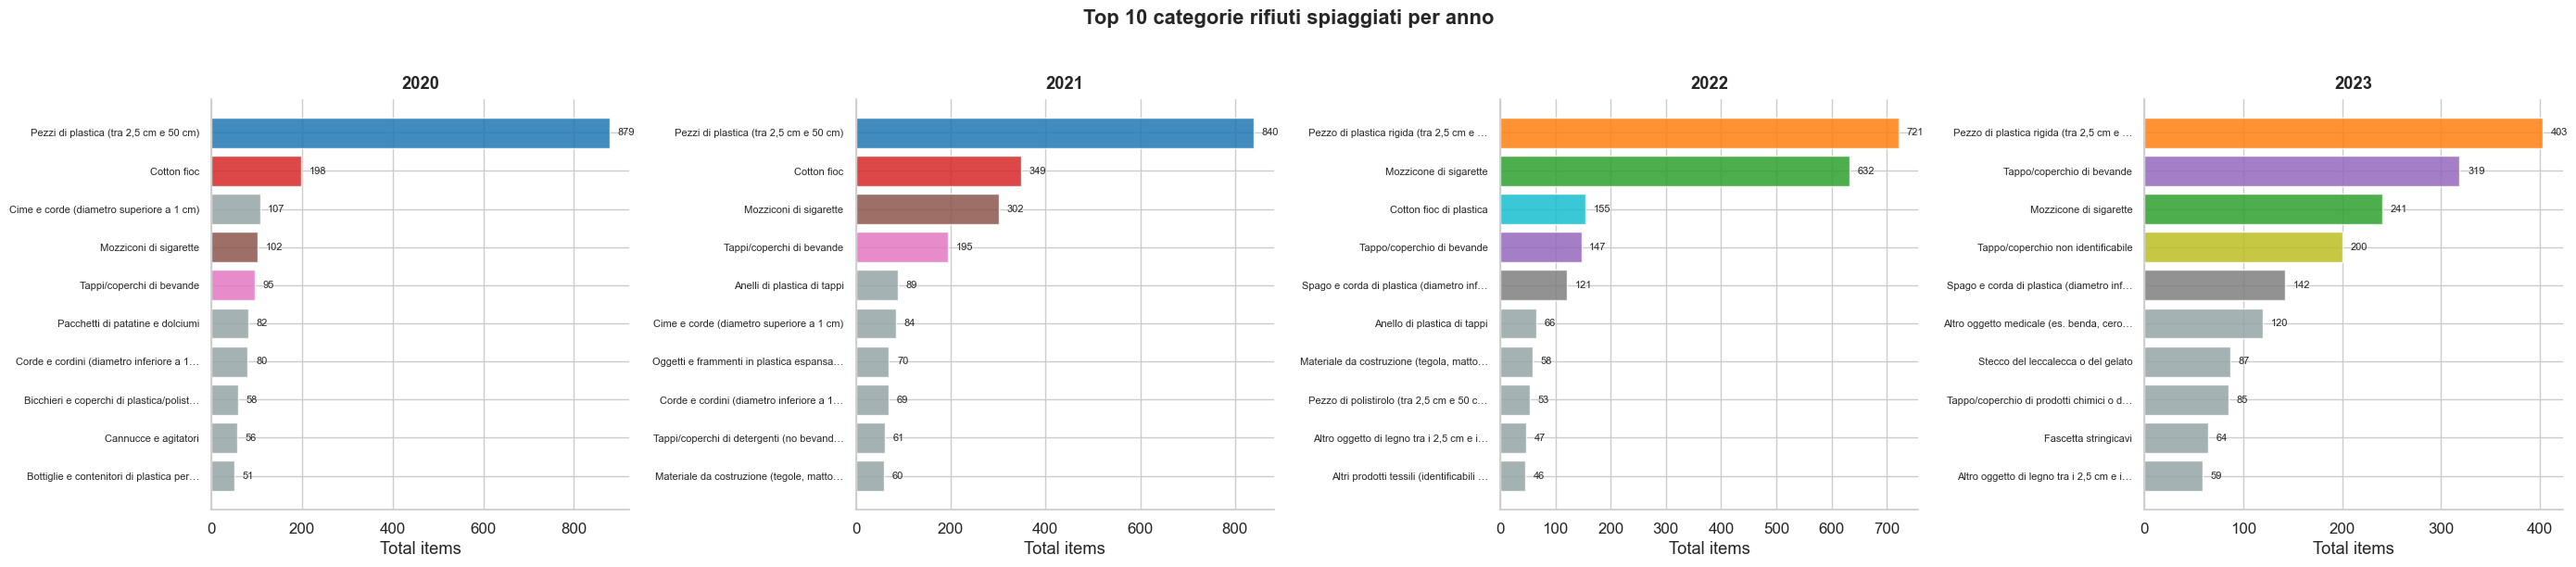

In [9]:
years = sorted(rif_df['year'].dropna().unique().astype(int))
n_years = len(years)
fig, axes = plt.subplots(1, n_years, figsize=(7 * n_years, 6), sharey=False)
if n_years == 1: axes = [axes]

top10_global = cat_total.head(10).index.tolist()
palette = plt.cm.tab10.colors
color_map = {desc: palette[i % 10] for i, desc in enumerate(top10_global)}

for ax, yr in zip(axes, years):
    yr_data = (rif_df[rif_df['year'] == yr]
               .groupby('desc')['n_items'].sum()
               .sort_values(ascending=False).head(10))
    colors = [color_map.get(c, '#95a5a6') for c in yr_data.index[::-1]]
    bars = ax.barh(yr_data.index[::-1], yr_data.values[::-1], color=colors, alpha=0.85)
    for bar, val in zip(bars, yr_data.values[::-1]):
        ax.text(val + yr_data.max()*0.02, bar.get_y()+bar.get_height()/2,
                f'{int(val):,}', va='center', fontsize=8)
    ax.set_title(str(int(yr)), fontweight='bold', pad=8)
    ax.set_xlabel('Total items')
    ax.tick_params(axis='y', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Top 10 categorie rifiuti spiaggiati per anno', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'beach_top_categories_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Beach Litter — Composizione per anno (top 5, stacked)

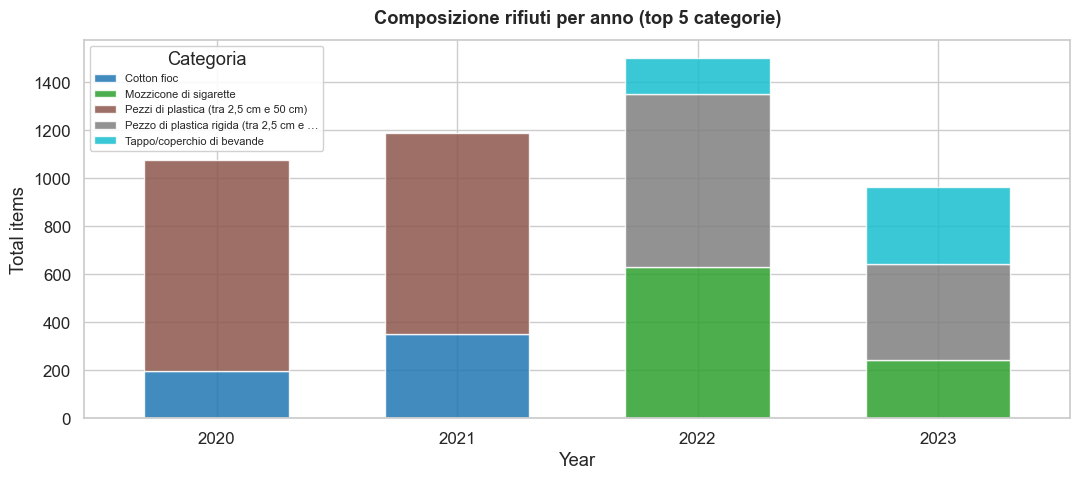

In [10]:
top5_cats = cat_total.head(5).index.tolist()
cat_year = (rif_df[rif_df['desc'].isin(top5_cats)]
            .groupby(['year','desc'])['n_items'].sum()
            .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(11, 5))
cat_year.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', alpha=0.85, width=0.6)
ax.set_title('Composizione rifiuti per anno (top 5 categorie)', fontweight='bold', pad=12)
ax.set_xlabel('Year'); ax.set_ylabel('Total items')
ax.legend(title='Categoria', loc='upper left', fontsize=8, framealpha=0.9)
ax.set_xticklabels(cat_year.index.astype(int), rotation=0)
plt.tight_layout()
plt.savefig(FIGS / 'beach_category_by_year.png', dpi=150)
plt.show()

## 9. Beach Litter — Attribuzione sorgente

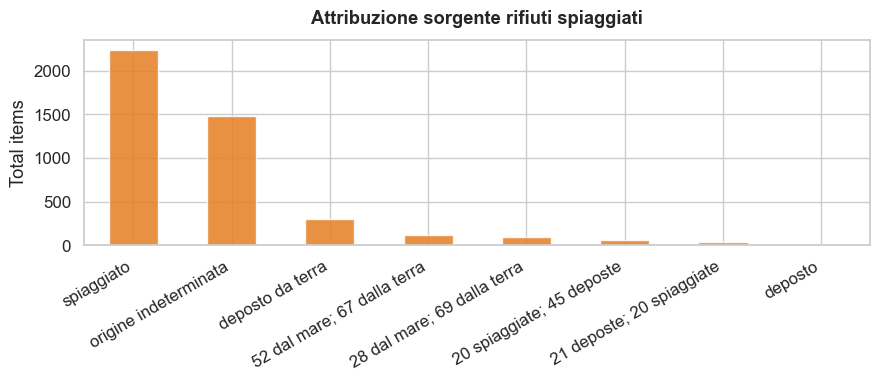

In [11]:
src = rif_df.groupby('source')['n_items'].sum().dropna().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
src.plot(kind='bar', ax=ax, color='#e67e22', alpha=0.85, width=0.5)
ax.set_title('Attribuzione sorgente rifiuti spiaggiati', fontweight='bold', pad=12)
ax.set_xlabel(''); ax.set_ylabel('Total items')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGS / 'beach_source_attribution.png', dpi=150)
plt.show()

---
## 10. Floating Litter — Composizione materiali

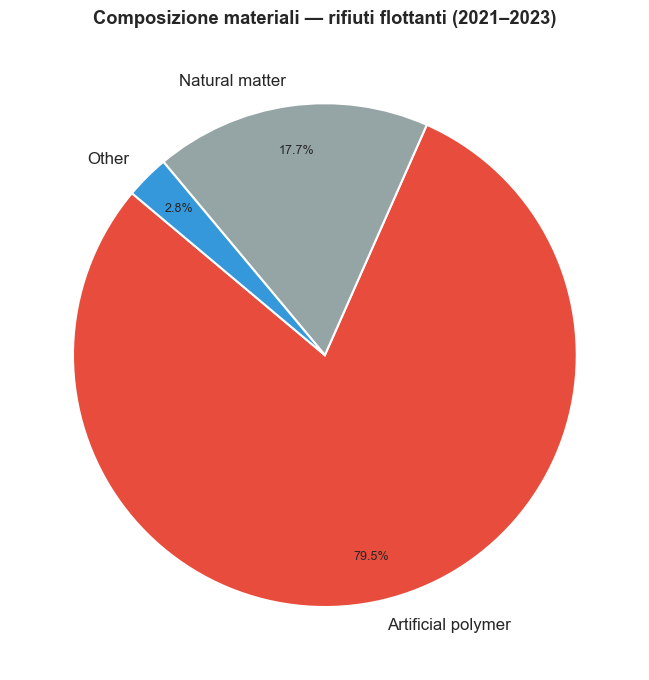

In [23]:
mat = (floating['material']
       .str.strip()
       .replace({'Polimeri artificiali': 'Artificial polymer',
                 'Materiale naturale':   'Natural matter',
                 'Alghe/Fanerogame':     'Natural matter',
                 'Polimeri':       'Artificial polymer',
                 'Rifiuto alimentare':   'Food waste',
                 'Gomma':                'Rubber',
                 'Metallo':              'Metal',
                 'Vetro/ceramica':       'Glass/ceramics',
                 'Tessile':              'Textiles',
                 'Carta/cartone':        'Paper/cardboard'})
       .value_counts())
threshold = mat.sum() * 0.02
mat_g = mat[mat >= threshold].copy()
mat_g['Other'] = mat[mat < threshold].sum()
mat_g = mat_g.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors_pie = ['#e74c3c','#95a5a6','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
wedges, texts, autotexts = ax.pie(
    mat_g.values, labels=mat_g.index, autopct='%1.1f%%',
    colors=colors_pie[:len(mat_g)], startangle=140, pctdistance=0.82,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
for at in autotexts: at.set_fontsize(9)
years_range = f"{int(floating['year'].dropna().min())}–{int(floating['year'].dropna().max())}"
ax.set_title(f'Composizione materiali — rifiuti flottanti ({years_range})',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(FIGS / 'floating_material_pie.png', dpi=150)
plt.show()

## 11. Floating Litter — Stagionalità

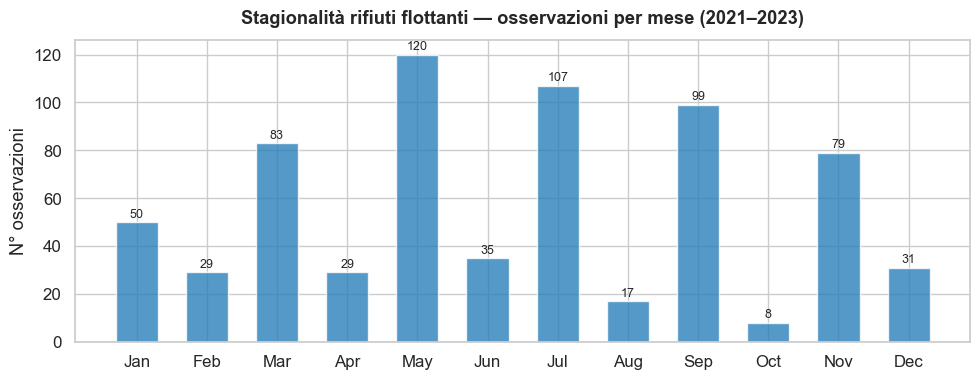

In [13]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = (floating.dropna(subset=['month'])
           .assign(month=lambda d: d['month'].astype(int))
           .groupby('month').size()
           .reindex(range(1, 13), fill_value=0))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(1,13), monthly.values, color='#2980b9', alpha=0.8, width=0.6)
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names)
years_range = f"{int(floating['year'].dropna().min())}–{int(floating['year'].dropna().max())}"
ax.set_title(f'Stagionalità rifiuti flottanti — osservazioni per mese ({years_range})',
             fontweight='bold', pad=12)
ax.set_ylabel('N° osservazioni')
for bar, val in zip(bars, monthly.values):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'floating_seasonality.png', dpi=150)
plt.show()

## 12. Floating Litter — Trend materiali per anno

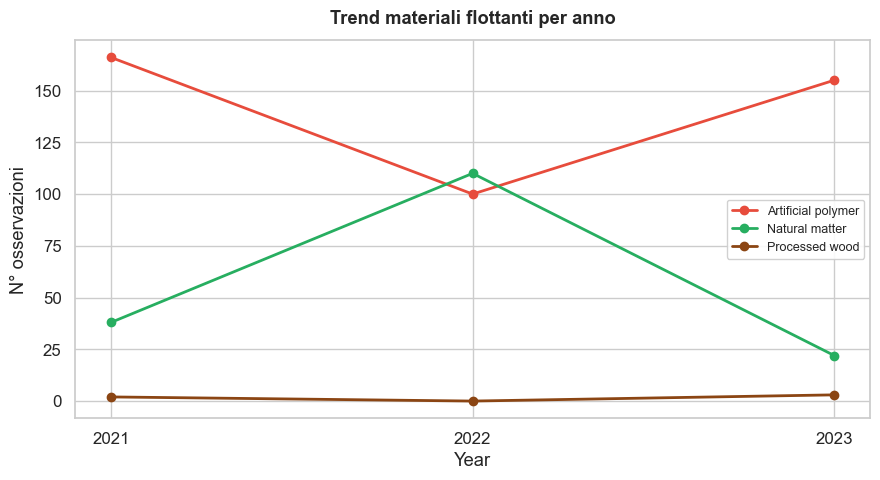

In [14]:
top_mats = floating['material'].value_counts().head(4).index.tolist()
mat_year = (floating[floating['material'].isin(top_mats)]
            .assign(year=lambda d: pd.to_numeric(d['year'], errors='coerce'))
            .dropna(subset=['year'])
            .assign(year=lambda d: d['year'].astype(int))
            .groupby(['year','material']).size().unstack(fill_value=0))

mat_colors = {'Artificial polymer':'#e74c3c', 'Natural matter':'#27ae60',
              'Processed wood':'#8B4513', 'Food waste':'#f39c12',
              'Rubber':'#9b59b6', 'Metal':'#95a5a6'}

fig, ax = plt.subplots(figsize=(9, 5))
for mat_name in mat_year.columns:
    ax.plot(mat_year.index, mat_year[mat_name], marker='o', linewidth=2,
            color=mat_colors.get(mat_name, '#666'), label=mat_name)
ax.set_title('Trend materiali flottanti per anno', fontweight='bold', pad=12)
ax.set_xlabel('Year'); ax.set_ylabel('N° osservazioni')
ax.set_xticks(mat_year.index)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(FIGS / 'floating_material_trend.png', dpi=150)
plt.show()

---
## 13. Summary statistics

In [15]:
summary = (
    beach.groupby('beach_id')
    .agg(
        name=('beach_name','first'),
        surveys=('survey_id','count'),
        mean_items_100m=('items_per_100m','mean'),
        median_items_100m=('items_per_100m','median'),
        max_items_100m=('items_per_100m','max'),
        trend=('items_per_100m', lambda x:
               '↑' if x.iloc[-1] > x.iloc[0] else '↓' if x.iloc[-1] < x.iloc[0] else '→')
    )
    .round(1)
)
print('EU indicative threshold: 150 items/100m')
summary

EU indicative threshold: 150 items/100m


,name,surveys,mean_items_100m,median_items_100m,max_items_100m,trend
beach_id,,,,,,
MWE_SAR_1,Alghero Lido,5,507.6,526.0,687.0,↓
MWE_SAR_2,Cagliari Poetto,7,270.0,258.0,358.0,↑
MWE_SAR_3,Castiadas Costa Rei,8,168.9,135.5,514.0,↑
MWE_SAR_4,Oristano Is Arenas,8,538.6,537.5,1421.0,↓
MWE_SAR_5,San Teodoro La Cinta,7,57.6,49.0,124.0,↑
MWE_SAR_6,Sant'Anna Arresi Porto Pino,6,193.2,152.5,403.0,↑


---
## 14. Spatial Hazard — Sardinia polygon

In [16]:
sardinia_box  = box(8.1, 38.86, 9.87, 41.25)
land          = gpd.read_file(get_path('naturalearth.land'))
sardinia_gdf  = land.clip(sardinia_box)
sardinia_poly = sardinia_gdf.geometry.iloc[0]
if sardinia_poly.geom_type == 'MultiPolygon':
    sardinia_poly = max(sardinia_poly.geoms, key=lambda p: p.area)
print(f'Centroid: {sardinia_poly.centroid.x:.2f}, {sardinia_poly.centroid.y:.2f}')

Centroid: 9.03, 40.07


## 15. Spatial Hazard — Station aggregation & normalization

In [17]:
beach_st = (
    beach.groupby('beach_id').agg(
        lat=('lat','first'), lon=('lon','first'),
        name=('beach_name','first'),
        items_100m=('items_per_100m','mean'),
        n_surveys=('survey_id','count')
    ).reset_index().dropna(subset=['lat','lon'])
)
float_st = (
    floating.groupby('station_id').agg(
        lat=('lat_station','first'), lon=('lon_station','first'),
        n_obs=('station_id','count'),
        plastic_pct=('material', lambda x: (x=='Artificial polymer').sum()/len(x)*100)
    ).reset_index().dropna(subset=['lat','lon'])
)

def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-10)

beach_st['score'] = minmax(beach_st['items_100m'])
float_st['score'] = minmax(float_st['n_obs'])

print('Beach stations:')
print(beach_st[['name','items_100m','score']].sort_values('score', ascending=False).round(3).to_string(index=False))

Beach stations:
                       name  items_100m  score
         Oristano Is Arenas     538.625  1.000
               Alghero Lido     507.600  0.936
            Cagliari Poetto     270.000  0.442
Sant'Anna Arresi Porto Pino     193.167  0.282
        Castiadas Costa Rei     168.875  0.231
       San Teodoro La Cinta      57.571  0.000


## 16. Spatial Hazard — Coastal grid + IDW interpolation

In [18]:
# 0.12° ≈ 10 km grid
lons = np.arange(8.1, 9.9, 0.12)
lats = np.arange(38.86, 41.25, 0.12)
lon_g, lat_g = np.meshgrid(lons, lats)
lon_f, lat_f = lon_g.ravel(), lat_g.ravel()

sardinia_buf = sardinia_poly.buffer(0.25)
mask = np.array([sardinia_buf.contains(Point(lo, la)) for lo, la in zip(lon_f, lat_f)])
lon_c, lat_c = lon_f[mask], lat_f[mask]
print(f'Grid cells: {mask.sum()}')

def idw(g_lons, g_lats, s_lons, s_lats, scores, power=2, radius=1.0):
    result = np.full(len(g_lons), np.nan)
    tree = cKDTree(np.column_stack([s_lons, s_lats]))
    for i, (glo, gla) in enumerate(zip(g_lons, g_lats)):
        idxs = tree.query_ball_point([glo, gla], radius)
        if not idxs: continue
        d = np.sqrt((s_lons[idxs]-glo)**2 + (s_lats[idxs]-gla)**2)
        w = 1 / (d**power + 1e-9)
        result[i] = np.sum(w * scores[idxs]) / np.sum(w)
    return result

beach_interp = idw(lon_c, lat_c, beach_st['lon'].values, beach_st['lat'].values,
                   beach_st['score'].values, radius=1.0)
float_interp = idw(lon_c, lat_c, float_st['lon'].values, float_st['lat'].values,
                   float_st['score'].values, radius=1.2)

hazard = np.nanmean(np.stack([beach_interp, float_interp], axis=1), axis=1)

grid_df = pd.DataFrame({
    'lon': lon_c, 'lat': lat_c,
    'beach_score': beach_interp, 'float_score': float_interp,
    'hazard_index': hazard
}).dropna(subset=['hazard_index'])

grid_df['hazard_class'] = pd.cut(
    grid_df['hazard_index'], bins=[0,.2,.4,.6,.8,1.],
    labels=['Very Low','Low','Medium','High','Very High'], include_lowest=True
)
grid_df.to_csv(OUT / 'hazard_grid.csv', index=False)
grid_df['hazard_class'].value_counts().sort_index()

Grid cells: 289


hazard_class
Very Low      51
Low          129
Medium        96
High          13
Very High      0
Name: count, dtype: int64

## 17. Spatial Hazard — Static 3-panel map

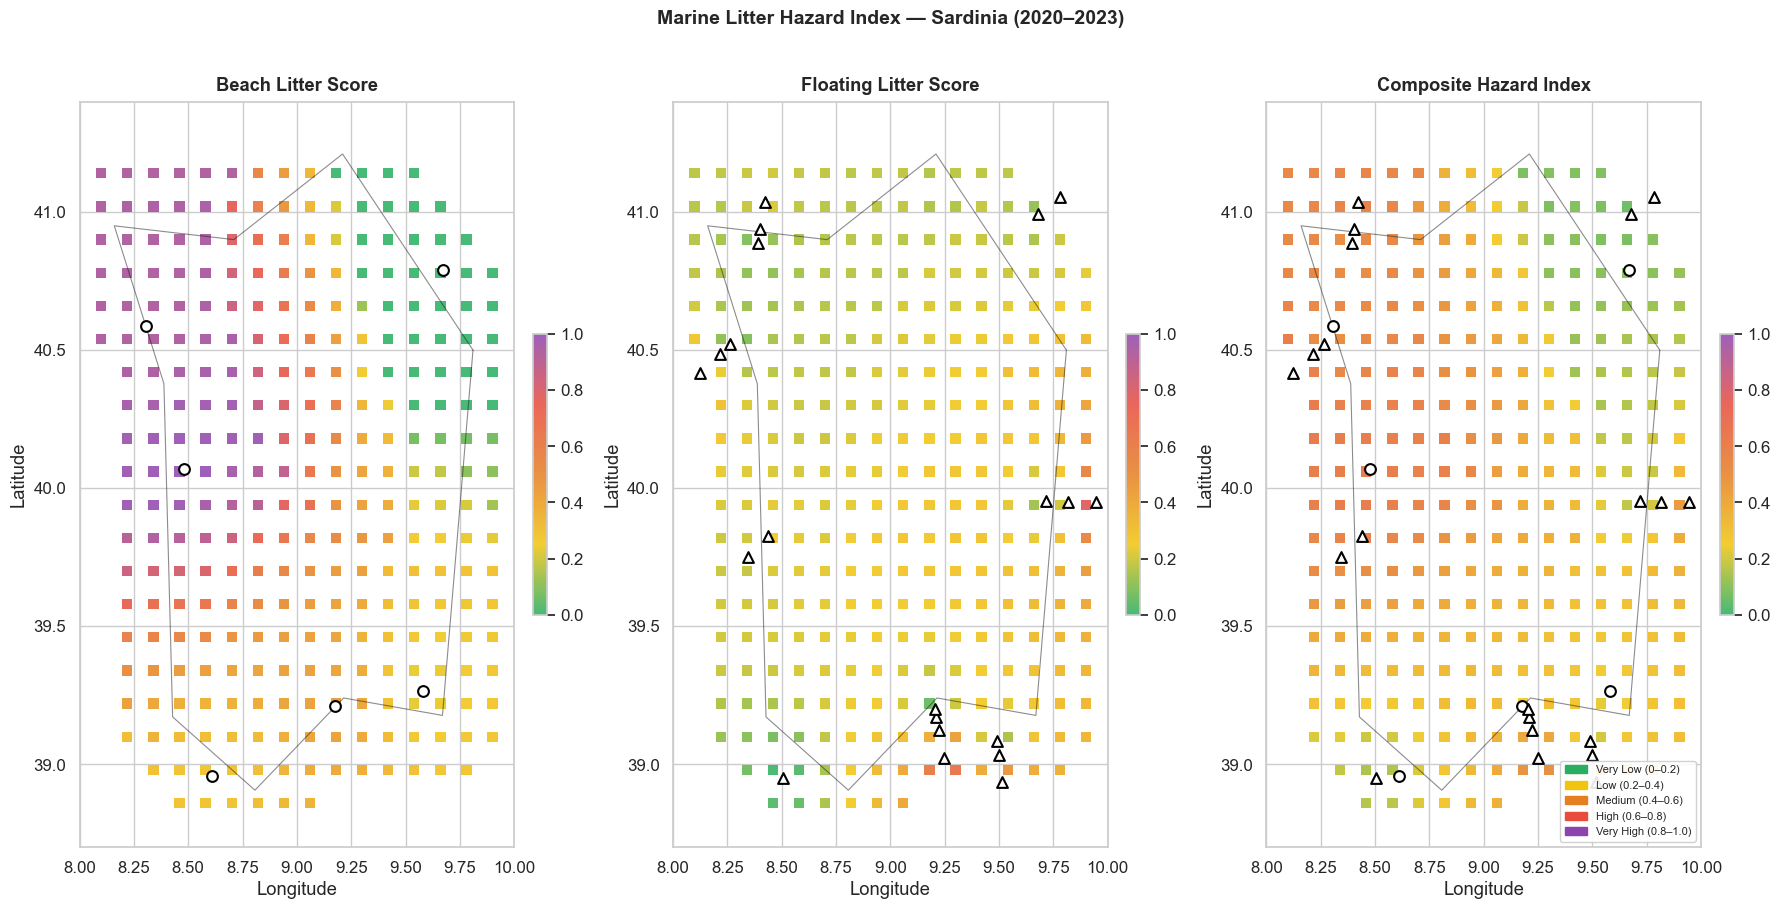

In [19]:
cmap = LinearSegmentedColormap.from_list('hazard',
       ['#27ae60','#f1c40f','#e67e22','#e74c3c','#8e44ad'])

fig, axes = plt.subplots(1, 3, figsize=(18, 9))
for ax, title, col in zip(
    axes,
    ['Beach Litter Score','Floating Litter Score','Composite Hazard Index'],
    ['beach_score','float_score','hazard_index']
):
    sc = ax.scatter(grid_df['lon'], grid_df['lat'],
                    c=grid_df[col], cmap=cmap, s=55, alpha=0.85,
                    vmin=0, vmax=1, edgecolors='none', marker='s')
    cx, cy = sardinia_poly.exterior.xy
    ax.plot(cx, cy, 'k-', linewidth=0.8, alpha=0.5)
    if col in ('beach_score','hazard_index'):
        ax.scatter(beach_st['lon'], beach_st['lat'], marker='o',
                   s=60, c='white', edgecolors='black', lw=1.5, zorder=5)
    if col in ('float_score','hazard_index'):
        ax.scatter(float_st['lon'], float_st['lat'], marker='^',
                   s=60, c='white', edgecolors='black', lw=1.5, zorder=5)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_xlim(8.0, 10.0); ax.set_ylim(38.7, 41.4)

legend_el = [
    mpatches.Patch(color='#27ae60', label='Very Low (0–0.2)'),
    mpatches.Patch(color='#f1c40f', label='Low (0.2–0.4)'),
    mpatches.Patch(color='#e67e22', label='Medium (0.4–0.6)'),
    mpatches.Patch(color='#e74c3c', label='High (0.6–0.8)'),
    mpatches.Patch(color='#8e44ad', label='Very High (0.8–1.0)'),
]
axes[2].legend(handles=legend_el, loc='lower right', fontsize=8, framealpha=0.9)
fig.suptitle('Marine Litter Hazard Index — Sardinia (2020–2023)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'hazard_index_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Spatial Hazard — Interactive map

In [ ]:
import json as _json

def hcolor(v):
    if v is None:  return '#cccccc'
    if v < 0.2: return '#27ae60'
    if v < 0.4: return '#f1c40f'
    if v < 0.6: return '#e67e22'
    if v < 0.8: return '#e74c3c'
    return '#8e44ad'

m = folium.Map(location=[40.1, 9.0], zoom_start=7, tiles='CartoDB positron')

# ── Comuni layer (default ON) ────────────────────────────────────────────────
comuni_gdf_f = gpd.read_file(OUT / 'comuni_hazard.geojson')
comuni_gdf_f['hazard_by_year'] = comuni_gdf_f['hazard_by_year'].apply(
    lambda x: _json.loads(x) if isinstance(x, str) else x
)
LATEST_YR = sorted({yr for d in comuni_gdf_f['hazard_by_year'] for yr in d})[- 1]

comuni_grp = folium.FeatureGroup(name='🏛️ Comuni (latest year)', show=True)
for _, row in comuni_gdf_f.iterrows():
    h    = row['hazard_by_year'].get(str(LATEST_YR))
    nome = row['name']
    prov = row.get('prov', '')
    all_yrs = ' | '.join(
        f"{yr}: {v:.2f}" for yr, v in sorted(row['hazard_by_year'].items()) if v is not None
    )
    geom  = row.geometry
    polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
    for poly in polys:
        coords = [[lat, lon] for lon, lat in poly.exterior.coords]
        folium.Polygon(
            locations=coords,
            color='white', weight=0.6,
            fill=True, fill_color=hcolor(h), fill_opacity=0.75,
            tooltip=f"<b>{nome}</b> ({prov})<br>{LATEST_YR}: {h:.2f}" if h else nome,
            popup=folium.Popup(
                f"<b>{nome}</b><br><small>{all_yrs}</small>", max_width=220)
        ).add_to(comuni_grp)
comuni_grp.add_to(m)

# ── Hazard grid (hidden by default, available in layer control) ───────────────
cell = 0.06
for layer_name, col, show in [
    ('🗺️ Hazard Grid (composite)', 'hazard_index', False),
    ('🏖️ Beach Score',             'beach_score',  False),
    ('🌊 Floating Score',          'float_score',  False),
]:
    grp = folium.FeatureGroup(name=layer_name, show=show)
    for _, row in grid_df.dropna(subset=[col]).iterrows():
        v = row[col]
        folium.Rectangle(
            bounds=[[row['lat']-cell, row['lon']-cell],
                    [row['lat']+cell, row['lon']+cell]],
            color=None, fill=True, fill_color=hcolor(v), fill_opacity=0.55,
            tooltip=(f"Hazard: {row['hazard_index']:.2f} ({row['hazard_class']}) | "
                     f"Beach: {row['beach_score']:.2f} | Float: {row['float_score']:.2f}")
        ).add_to(grp)
    grp.add_to(m)

# ── Station markers ───────────────────────────────────────────────────────────
st_grp = folium.FeatureGroup(name='📍 Stations', show=True)
for _, r in beach_st.iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lon']], radius=10,
        color='white', weight=2.5,
        fill=True, fill_color=hcolor(r['score']), fill_opacity=0.95,
        popup=folium.Popup(
            f"<b>{r['name']}</b><br>items/100m: <b>{r['items_100m']:.1f}</b><br>"
            f"score: <b>{r['score']:.2f}</b>", max_width=200),
        tooltip=f"🏖️ {r['name']}: {r['items_100m']:.0f} items/100m"
    ).add_to(st_grp)
for _, r in float_st.iterrows():
    folium.RegularPolygonMarker(
        location=[r['lat'], r['lon']], number_of_sides=3, radius=9,
        color='white', weight=2,
        fill=True, fill_color=hcolor(r['score']), fill_opacity=0.9,
        popup=folium.Popup(
            f"<b>{r['station_id']}</b><br>obs: <b>{r['n_obs']}</b><br>"
            f"plastic: <b>{r['plastic_pct']:.1f}%</b><br>score: <b>{r['score']:.2f}</b>",
            max_width=200),
        tooltip=f"🌊 {r['station_id']}: {r['n_obs']} obs"
    ).add_to(st_grp)
st_grp.add_to(m)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_html = """
<div style='position:fixed;bottom:40px;left:40px;z-index:1000;background:white;
     padding:14px 18px;border-radius:8px;box-shadow:2px 2px 8px rgba(0,0,0,0.2);
     font-family:Arial,sans-serif;font-size:12px'>
  <b style='font-size:14px'>Hazard Index</b><br>
  <small style='color:#888'>MSFD D10 · Sardinia · 2020–2023</small>
  <hr style='margin:8px 0;border-color:#eee'>
  <span style='background:#27ae60;padding:2px 8px;border-radius:3px;color:white'>Very Low</span> &lt;0.2<br><br>
  <span style='background:#f1c40f;padding:2px 8px;border-radius:3px'>Low</span> 0.2–0.4<br><br>
  <span style='background:#e67e22;padding:2px 8px;border-radius:3px;color:white'>Medium</span> 0.4–0.6<br><br>
  <span style='background:#e74c3c;padding:2px 8px;border-radius:3px;color:white'>High</span> 0.6–0.8<br><br>
  <span style='background:#8e44ad;padding:2px 8px;border-radius:3px;color:white'>V.High</span> &gt;0.8
  <hr style='margin:8px 0;border-color:#eee'>
  ● beach &nbsp; ▲ floating<br>
  <small style='color:#777'>IDW · 10km grid · 2 compartments</small>
</div>"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False, position='topright').add_to(m)
m.save(str(MAPS / 'sardinia_hazard_index.html'))
print(f'Saved: sardinia_hazard_index.html  (default layer: comuni {LATEST_YR})')

## 19. Spatial Hazard — Hotspot analysis

In [21]:
print('Hazard class distribution:')
print(grid_df['hazard_class'].value_counts().sort_index())
print()
print('Top 10 hotspot cells:')
print(grid_df.nlargest(10,'hazard_index')[['lon','lat','beach_score','float_score','hazard_index','hazard_class']].round(3).to_string(index=False))
print()
print('Beach station ranking:')
print(beach_st[['name','items_100m','score']].sort_values('score',ascending=False).round(3).to_string(index=False))

Hazard class distribution:
hazard_class
Very Low      51
Low          129
Medium        96
High          13
Very High      0
Name: count, dtype: int64

Top 10 hotspot cells:
 lon   lat  beach_score  float_score  hazard_index hazard_class
8.22 40.30        0.963        0.296         0.629         High
8.22 40.18        0.980        0.265         0.622         High
8.34 40.18        0.990        0.235         0.612         High
8.22 40.06        0.988        0.235         0.612         High
8.34 40.06        0.996        0.226         0.611         High
8.46 39.94        0.986        0.233         0.609         High
8.10 40.54        0.943        0.273         0.608         High
8.46 40.06        1.000        0.215         0.608         High
8.34 39.94        0.995        0.220         0.607         High
8.46 40.18        0.996        0.219         0.607         High

Beach station ranking:
                       name  items_100m  score
         Oristano Is Arenas     538.625  1.000
    

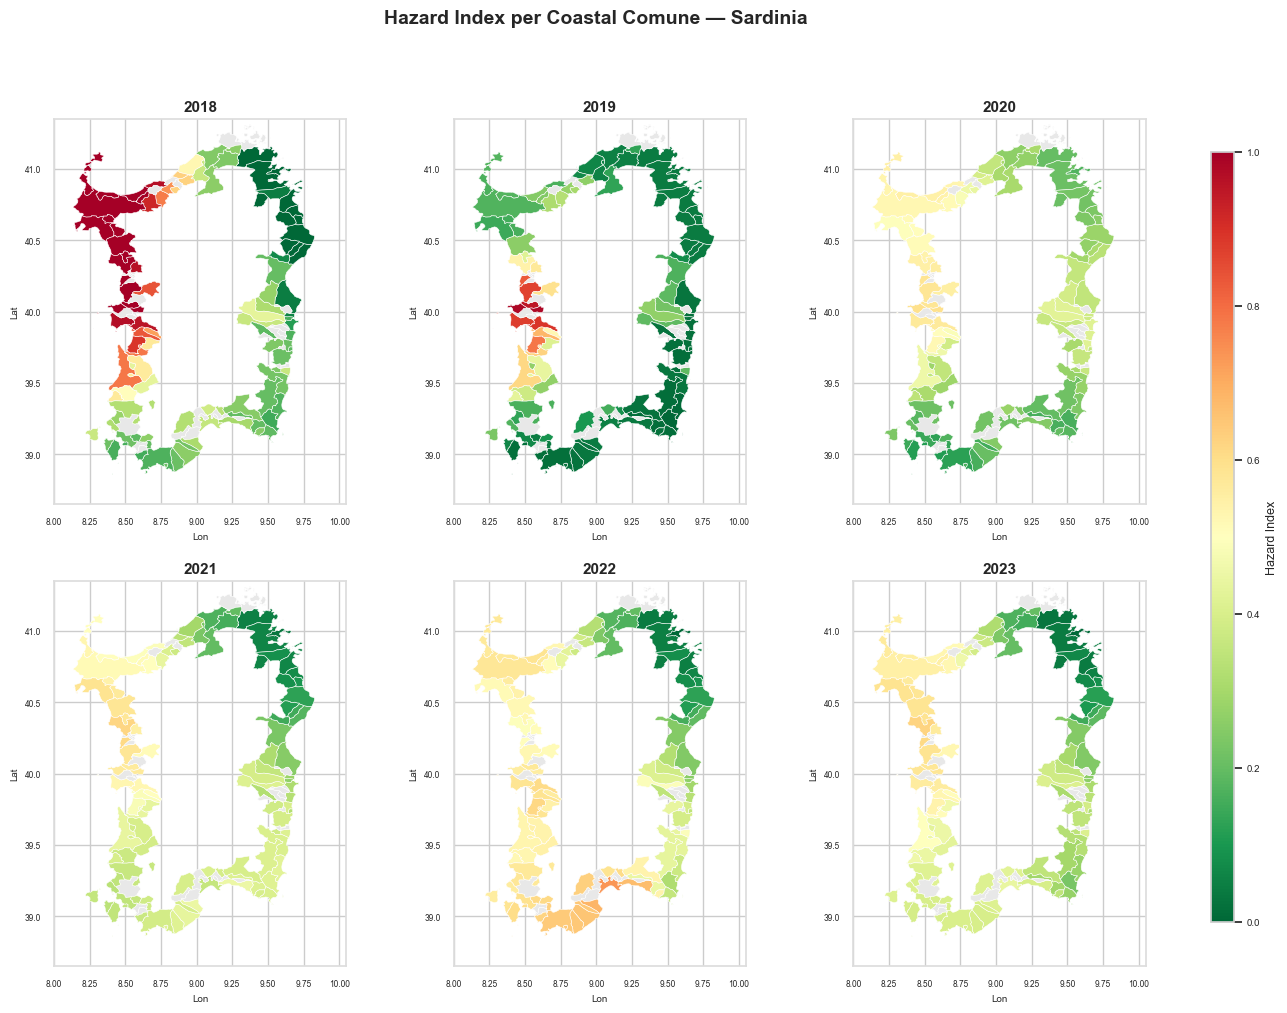

In [22]:
import json, math
import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

comuni_gdf = gpd.read_file(OUT / 'comuni_hazard.geojson')
comuni_gdf['hazard_by_year'] = comuni_gdf['hazard_by_year'].apply(
    lambda x: json.loads(x) if isinstance(x, str) else x
)

YEARS = sorted({yr for d in comuni_gdf['hazard_by_year'] for yr in d.keys()})
ncols = 3
nrows = math.ceil(len(YEARS) / ncols)

cmap  = plt.cm.RdYlGn_r
norm_h = Normalize(0, 1)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5.5 * nrows),
                         facecolor='white')
axes_flat = list(axes.flat) if hasattr(axes, 'flat') else [axes]

for ax, yr in zip(axes_flat, YEARS):
    ax.set_facecolor('white')
    ax.set_aspect('equal')
    for _, row in comuni_gdf.iterrows():
        h = row['hazard_by_year'].get(str(yr))
        color = cmap(norm_h(h)) if h is not None else '#e8e8e8'
        geom = row.geometry
        polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
        for poly in polys:
            xs, ys = poly.exterior.xy
            ax.fill(xs, ys, color=color, linewidth=0.4, edgecolor='white')
    ax.set_title(yr, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlim(8.0, 10.05); ax.set_ylim(38.65, 41.35)
    ax.tick_params(labelsize=6, color='#aaa')
    ax.set_xlabel('Lon', fontsize=7); ax.set_ylabel('Lat', fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#ddd')

for ax in axes_flat[len(YEARS):]:
    ax.set_visible(False)

# colorbar in dedicated axis to the right — no overlap
sm = ScalarMappable(cmap=cmap, norm=norm_h)
sm.set_array([])
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Hazard Index', fontsize=9)
cbar.ax.tick_params(labelsize=7)

fig.suptitle('Hazard Index per Coastal Comune — Sardinia', fontsize=14,
             fontweight='bold')
plt.savefig(FIGS / 'comuni_hazard_map.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

---
## 20. Coastal Hazard — Per-comune refinement